# Linear Regression Analysis in R

This notebook demonstrates a simple linear regression analysis using R to model Salary based on YearsExperience.

## Objective

This analysis examines how annual salary varies with years of professional experience. The workflow includes data inspection, visualization with ggplot2, model fitting with `lm()`, and interpretation of regression output.

## Import Libraries

In [1]:
library(tidyverse)
library(ggplot2)

theme_set(theme_minimal(base_size = 12))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Load Dataset

The dataset `regression_data.csv` contains observations of experience and salary.

In [2]:
DATA_FILE <- "regression_data.csv"

df <- read_csv(DATA_FILE, show_col_types = FALSE)
head(df)

YearsExperience,Salary
<dbl>,<dbl>
1.1,39343
1.3,46205
1.5,37731
2.0,43525
2.2,39891
2.9,56642


## Inspect Dataset

We review the structure and dimensions of the data frame.

In [3]:
cat("Number of observations:", nrow(df), "\n")
cat("Number of variables:", ncol(df), "\n\n")
str(df)

Number of observations: 10 
Number of variables: 2 

spc_tbl_ [10 × 2] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ YearsExperience: num [1:10] 1.1 1.3 1.5 2 2.2 2.9 3 3.2 3.7 4
 $ Salary         : num [1:10] 39343 46205 37731 43525 39891 ...
 - attr(*, "spec")=
  .. cols(
  ..   YearsExperience = col_double(),
  ..   Salary = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


## Summary Statistics

Summary statistics describe the distribution of each numeric variable.

In [4]:
summary(df)

 YearsExperience     Salary     
 Min.   :1.100   Min.   :37731  
 1st Qu.:1.625   1st Qu.:40800  
 Median :2.550   Median :50325  
 Mean   :2.490   Mean   :49834  
 3rd Qu.:3.150   3rd Qu.:57052  
 Max.   :4.000   Max.   :63218  

## Scatter Plot Visualization

The scatter plot reveals the overall pattern between experience and salary.

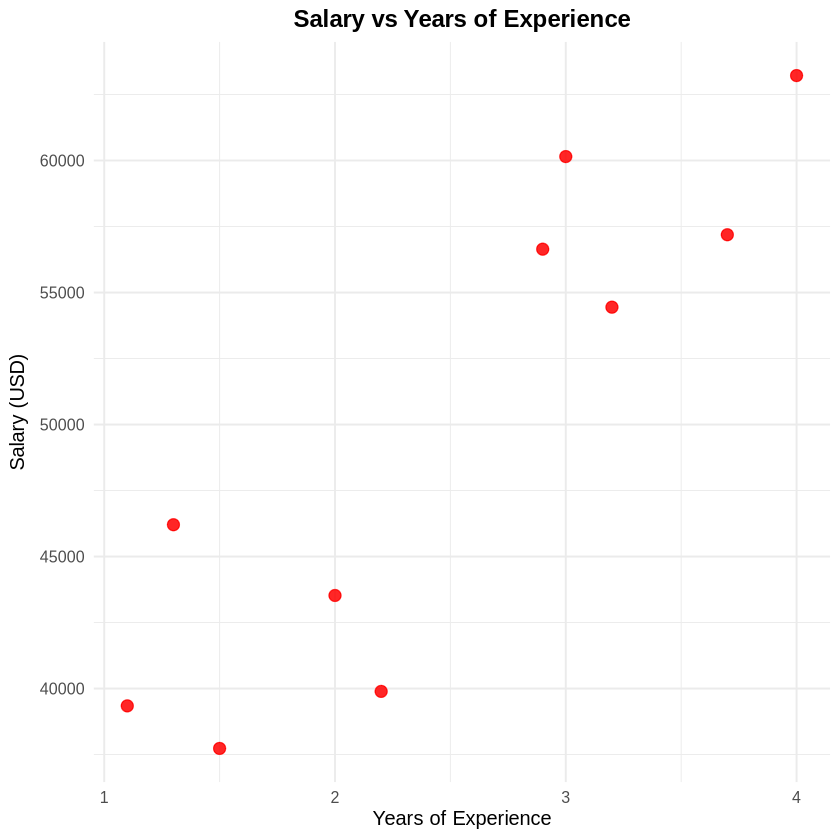

In [5]:
X_COLUMN <- "YearsExperience"
Y_COLUMN <- "Salary"

ggplot(df, aes(x = .data[[X_COLUMN]], y = .data[[Y_COLUMN]])) +
  geom_point(color = "red", size = 3, alpha = 0.85) +
  labs(
    title = "Salary vs Years of Experience",
    x = "Years of Experience",
    y = "Salary (USD)"
  ) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

## Linear Regression Model

We fit a linear model using ordinary least squares:

$$\text{Salary} = \beta_0 + \beta_1 \times \text{YearsExperience}$$

In [6]:
model_formula <- as.formula(paste(Y_COLUMN, "~", X_COLUMN))
model <- lm(model_formula, data = df)

coefficients <- coef(model)
cat("Intercept:", round(coefficients[[1]], 2), "\n")
cat("Slope:     ", round(coefficients[[2]], 2), "\n")

Intercept: 29203.52 
Slope:      8285.29 


## Regression-Line Visualization

Predicted values from the fitted model are overlaid as a blue regression line.

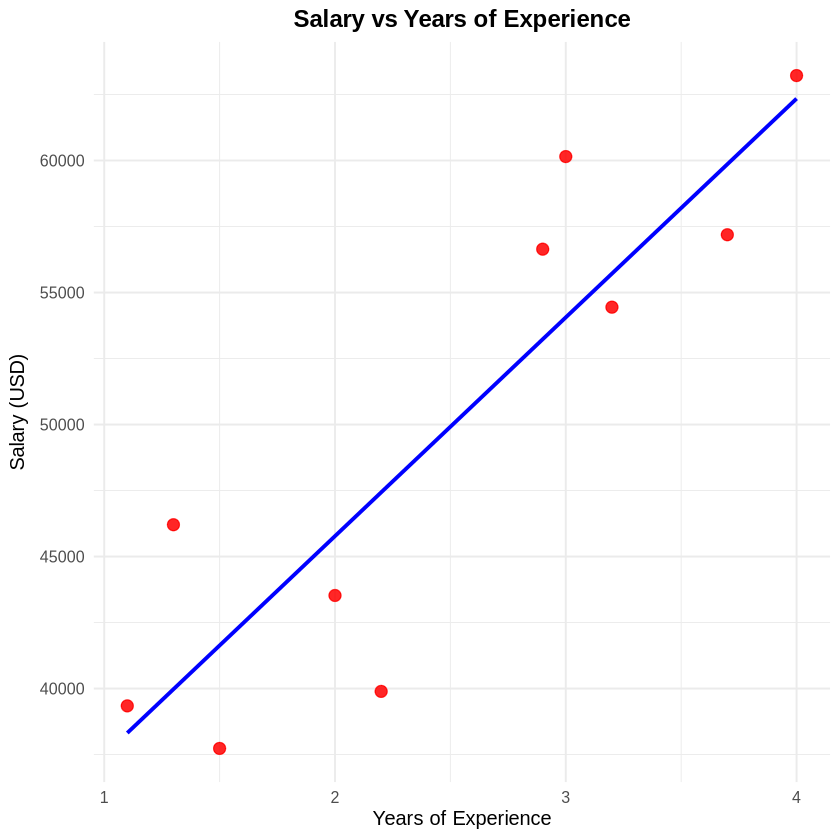

In [7]:
df$predicted <- predict(model, newdata = df)

ggplot(df, aes(x = .data[[X_COLUMN]], y = .data[[Y_COLUMN]])) +
  geom_point(color = "red", size = 3, alpha = 0.85) +
  geom_line(aes(y = predicted), color = "blue", linewidth = 1.1) +
  labs(
    title = "Salary vs Years of Experience",
    x = "Years of Experience",
    y = "Salary (USD)"
  ) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5))

## Model Evaluation

The `summary()` function reports coefficient estimates, standard errors, t-statistics, R-squared, and residual diagnostics.

In [8]:
model_summary <- summary(model)
print(model_summary)

cat("\nR-squared:", round(model_summary$r.squared, 4), "\n")
cat("Adjusted R-squared:", round(model_summary$adj.r.squared, 4), "\n")
cat("Residual standard error:", round(model_summary$sigma, 2), "\n")


Call:
lm(formula = model_formula, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407


R-squared: 0.7852 
Adjusted R-squared: 0.7583 
Residual standard error: 4680.26 


## Interpretation of Results

The slope coefficient quantifies the expected change in salary for each additional year of experience. The intercept estimates salary at zero years of experience and should be interpreted cautiously because it may lie outside the observed range of experience.

R-squared measures the proportion of salary variance explained by the model. Residual statistics from `summary(model)` indicate typical prediction error and help assess model adequacy. A significant positive slope with a high R-squared supports the conclusion that experience is a strong linear predictor of salary in this sample.

## Conclusion

This R notebook completed a reproducible linear regression analysis using tidyverse and ggplot2. The fitted model captures a positive relationship between experience and salary, and the visualization confirms that a linear trend is reasonable for these data.

Additional work could include residual plots, influence diagnostics, or hypothesis tests on the regression coefficients.